In [1]:
import pandas as pd
dataset=pd.read_csv("Placement.csv")

In [2]:
#)Replace the NaN values with correct value. And justify why you have chosen the same.
dataset.isnull().sum()

sl_no              0
gender             0
ssc_p              0
ssc_b              0
hsc_p              0
hsc_b              0
hsc_s              0
degree_p           0
degree_t           0
workex             0
etest_p            0
specialisation     0
mba_p              0
status             0
salary            67
dtype: int64

In [3]:
#Replacing 'nan' with '0' is best for this 'salary' data so this dependent can retain the reliable prediction
#dropna will loose 67 row of data whisch is large lose.
#mostly prediction is happening based on salary dependent if repace with Mean then changes considered as students are getting
#the salary will give error prediction so choosen the fillna as '0'.
dataset_filled=dataset
dataset_filled=dataset_filled['salary']=dataset_filled['salary'].fillna(0)

In [4]:
dataset_filled.isnull().sum()

np.int64(0)

In [5]:
#2)How many of them are not placed?
dataset

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,NaN
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210,211,M,80.60,Others,82.00,Others,Commerce,77.60,Comm&Mgmt,No,91.0,Mkt&Fin,74.49,Placed,400000.0
211,212,M,58.00,Others,60.00,Others,Science,72.00,Sci&Tech,No,74.0,Mkt&Fin,53.62,Placed,275000.0
212,213,M,67.00,Others,67.00,Others,Commerce,73.00,Comm&Mgmt,Yes,59.0,Mkt&Fin,69.72,Placed,295000.0
213,214,F,74.00,Others,66.00,Others,Commerce,58.00,Comm&Mgmt,No,70.0,Mkt&HR,60.23,Placed,204000.0


In [6]:
notplaced=0
for value in dataset['status']:
    if value=='Not Placed':
        notplaced+=1
print(f"Number of student(s) not placed :{notplaced}")    

    

Number of student(s) not placed :67


In [7]:
#3 Find the reason for non placement from the dataset?


In [8]:
dataset['status'].value_counts()

status
Placed        148
Not Placed     67
Name: count, dtype: int64

In [9]:
dataset=pd.get_dummies(dataset,columns=['status'],dtype=int,drop_first=True)
dataset

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,salary,status_Placed
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,270000.0,1
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,200000.0,1
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,250000.0,1
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,NaN,0
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,425000.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210,211,M,80.60,Others,82.00,Others,Commerce,77.60,Comm&Mgmt,No,91.0,Mkt&Fin,74.49,400000.0,1
211,212,M,58.00,Others,60.00,Others,Science,72.00,Sci&Tech,No,74.0,Mkt&Fin,53.62,275000.0,1
212,213,M,67.00,Others,67.00,Others,Commerce,73.00,Comm&Mgmt,Yes,59.0,Mkt&Fin,69.72,295000.0,1
213,214,F,74.00,Others,66.00,Others,Commerce,58.00,Comm&Mgmt,No,70.0,Mkt&HR,60.23,204000.0,1


In [11]:
placed= dataset[dataset['status_Placed']==1]
not_placed= dataset[dataset['status_Placed']==0]

In [12]:
#placed.drop(columns=['sl_no','salary'],inplace=True)
#not_placed.drop(columns=['sl_no','salary'],inplace=True)

In [13]:
from Variate import Univariate
qual,quan=Univariate.datatsetype(dataset)
placed_mean=placed[quan].mean()

In [14]:
placed_mean


sl_no               106.878378
ssc_p                71.721486
hsc_p                69.926554
degree_p             68.740541
etest_p              73.238041
mba_p                62.579392
salary           288655.405405
status_Placed         1.000000
dtype: float64

In [15]:
not_placed_mean=not_placed[quan].mean()
not_placed_mean

sl_no            110.477612
ssc_p             57.544030
hsc_p             58.395522
degree_p          61.134179
etest_p           69.587910
mba_p             61.612836
salary                  NaN
status_Placed      0.000000
dtype: float64

In [16]:
placed_count=0
placed_filter=[]
notplaced_filter=[]
not_placed_count=0
for column in quan:
    if placed_mean[column] >not_placed_mean[column]:
        placed_count+=1
        placed_filter.append(column)
    else:
        not_placed_count+=1
        notplaced_filter.append(column)
        
placed_filter
notplaced_filter


['sl_no', 'salary']

In [17]:
#solution:
#Reason for not placed is, academic career performance mean/average of the students of placed students are having higher academic pass marks than
#the not placed students.

In [18]:
#4)What kind of relation between salary and mba_p
dataset['salary'].corr(dataset['mba_p'])

np.float64(0.1750129406952748)

In [19]:
#Solution: Co-relation b/w is below low degree and mostly no relation b/w both based on value 0.175

In [20]:
#5)Which specialization is getting minimum salary?

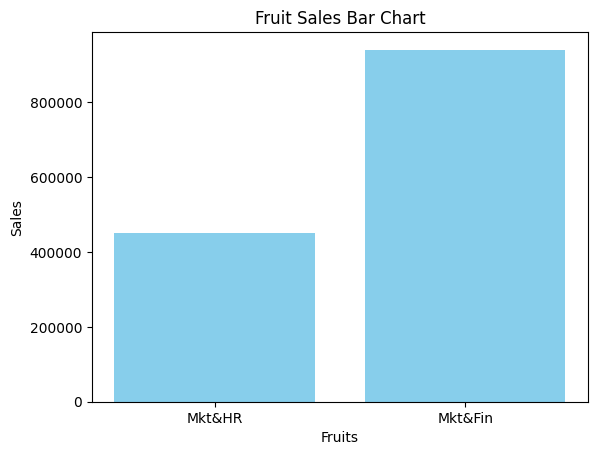

In [21]:
import matplotlib.pyplot as plt
plt.bar(dataset['specialisation'], dataset['salary'], color='skyblue')
# Add labels and title
plt.xlabel("Fruits")
plt.ylabel("Sales")
plt.title("Fruit Sales Bar Chart")

# Display the plot
plt.show()

In [22]:
#solution: Marketing and HR specilizaation is getting minimum salary

In [23]:
#6)How many of them getting above 500000 salary?
salary_count=0
for value in dataset['salary']:
    if value > 500000:
        salary_count+=1
print(f"{salary_count} students are getting above 500000 salary")

3 students are getting above 500000 salary


In [24]:
#7)Test the Analysis of Variance between etest_p and mba_p at signifance
#level 5%.(Make decision using Hypothesis Testing)
from scipy.stats import stats
stats.f_oneway(dataset['etest_p'],dataset['mba_p'])

C:\Users\Diwali 6\AppData\Local\Temp\ipykernel_16820\4265278179.py:4: DeprecationWarning: Please import `f_oneway` from the `scipy.stats` namespace; the `scipy.stats.stats` namespace is deprecated and will be removed in SciPy 2.0.0.
  stats.f_oneway(dataset['etest_p'],dataset['mba_p'])


F_onewayResult(statistic=np.float64(98.64487057324709), pvalue=np.float64(4.672547689133636e-21))

In [25]:
#Solution:
#Failed to Rejected null hypothesis since the prabobility value is above 0.05

In [26]:
#8)Test the similarity between the degree_t(Sci&Tech) and specialisation(Mkt&HR) with respect to salary at significance level of 5%.(Make
#decision using Hypothesis Testing)
from scipy.stats import ttest_ind

# Extract salaries
sci_tech_salary = dataset.loc[
    dataset['degree_t'] == 'Sci&Tech', 'salary'].dropna()

mkt_hr_salary = dataset.loc[
    dataset['specialisation'] == 'Mkt&HR', 'salary'].dropna()

# Independent t-test
t_stat, p_value = ttest_ind(
    sci_tech_salary,
    mkt_hr_salary,
    equal_var=False
)

t_stat, p_value

(np.float64(2.5503380163544116), np.float64(0.013410910580431394))

In [27]:
#solution:
#Average b/w the degree_t(Sci&Tech) and specialisation(Mkt&HR) with respect to salary is siginificant similarity below 0.05 
#so most of the the students from degree_t(Sci&Tech) and specialisation(Mkt&HR) are having similar getting salary.

In [28]:
dataset[quan]

,sl_no,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary,status_Placed
0,1,67.00,91.00,58.00,55.0,58.80,270000.0,1
1,2,79.33,78.33,77.48,86.5,66.28,200000.0,1
2,3,65.00,68.00,64.00,75.0,57.80,250000.0,1
3,4,56.00,52.00,52.00,66.0,59.43,NaN,0
4,5,85.80,73.60,73.30,96.8,55.50,425000.0,1
...,...,...,...,...,...,...,...,...
210,211,80.60,82.00,77.60,91.0,74.49,400000.0,1
211,212,58.00,60.00,72.00,74.0,53.62,275000.0,1
212,213,67.00,67.00,73.00,59.0,69.72,295000.0,1
213,214,74.00,66.00,58.00,70.0,60.23,204000.0,1


In [29]:
dataset.fillna(0)

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,salary,status_Placed
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,270000.0,1
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,200000.0,1
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,250000.0,1
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,0.0,0
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,425000.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210,211,M,80.60,Others,82.00,Others,Commerce,77.60,Comm&Mgmt,No,91.0,Mkt&Fin,74.49,400000.0,1
211,212,M,58.00,Others,60.00,Others,Science,72.00,Sci&Tech,No,74.0,Mkt&Fin,53.62,275000.0,1
212,213,M,67.00,Others,67.00,Others,Commerce,73.00,Comm&Mgmt,Yes,59.0,Mkt&Fin,69.72,295000.0,1
213,214,F,74.00,Others,66.00,Others,Commerce,58.00,Comm&Mgmt,No,70.0,Mkt&HR,60.23,204000.0,1


In [30]:
dataset[quan].fillna(0)

,sl_no,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary,status_Placed
0,1,67.00,91.00,58.00,55.0,58.80,270000.0,1
1,2,79.33,78.33,77.48,86.5,66.28,200000.0,1
2,3,65.00,68.00,64.00,75.0,57.80,250000.0,1
3,4,56.00,52.00,52.00,66.0,59.43,0.0,0
4,5,85.80,73.60,73.30,96.8,55.50,425000.0,1
...,...,...,...,...,...,...,...,...
210,211,80.60,82.00,77.60,91.0,74.49,400000.0,1
211,212,58.00,60.00,72.00,74.0,53.62,275000.0,1
212,213,67.00,67.00,73.00,59.0,69.72,295000.0,1
213,214,74.00,66.00,58.00,70.0,60.23,204000.0,1


In [31]:
dataset

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,salary,status_Placed
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,270000.0,1
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,200000.0,1
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,250000.0,1
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,NaN,0
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,425000.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210,211,M,80.60,Others,82.00,Others,Commerce,77.60,Comm&Mgmt,No,91.0,Mkt&Fin,74.49,400000.0,1
211,212,M,58.00,Others,60.00,Others,Science,72.00,Sci&Tech,No,74.0,Mkt&Fin,53.62,275000.0,1
212,213,M,67.00,Others,67.00,Others,Commerce,73.00,Comm&Mgmt,Yes,59.0,Mkt&Fin,69.72,295000.0,1
213,214,F,74.00,Others,66.00,Others,Commerce,58.00,Comm&Mgmt,No,70.0,Mkt&HR,60.23,204000.0,1


In [32]:
dataset_value
dataset[quan].std()
dataset_value


NameError: name 'dataset_value' is not defined

C:\Users\Diwali 6\AppData\Local\Temp\ipykernel_16820\260412198.py:10: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sb.distplot(z_score, kde=True)


np.float64(nan)

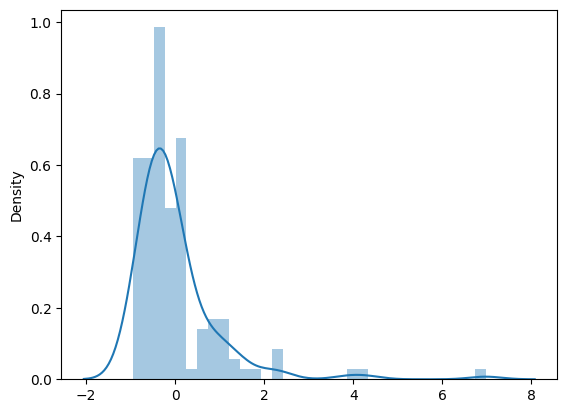

In [41]:
#9)Convert the normal distribution to standard normal distribution for salary column
import seaborn as sb
mean=0
std=0
dataset['salary'].fillna(0)
mean=dataset['salary'].mean()
std=dataset['salary'].std()
dataset_value= [i for i in dataset['salary']]
z_score = [((j-mean)/std) for j in dataset_value]
sb.distplot(z_score, kde=True)
sum(z_score)/len(z_score)

In [42]:
#Solution:
#x-axis zero represent avaerage salary of the most of the students
#x-axis >0 are getting more salary.
#x-axis <0 are getting less salary than average salary

In [43]:
#10)What is the probability Density Function of the salary range from 700000 to 900000?

In [60]:
def get_pdf_probability(dataset,startrange,endrange):
    from matplotlib import pyplot
    from scipy.stats import norm
    import seaborn as sns
    ax = sns.distplot(dataset,kde=False,kde_kws={'color':'blue'},color='Green')
    pyplot.axvline(startrange,color='Red')
    pyplot.axvline(endrange,color='Red')
    # generate a sample
    sample = dataset
    # calculate parameters
    sample_mean =sample.mean()
    sample_std = sample.std()
    print('Mean=%.3f, Standard Deviation=%.3f' % (sample_mean, sample_std))
    # define the distribution
    dist = norm(sample_mean, sample_std)
    
    # sample probabilities for a range of outcomes
    values = [value for value in range(startrange, endrange)]
    probabilities = [dist.pdf(value) for value in values]    
    prob=sum(probabilities)
    print("The area between range({},{}):{}".format(startrange,endrange,prob))
    return prob
    

C:\Users\Diwali 6\AppData\Local\Temp\ipykernel_16820\1672173389.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax = sns.distplot(dataset,kde=False,kde_kws={'color':'blue'},color='Green')


Mean=198702.326, Standard Deviation=154780.927
The area between range(700000,900000):0.0005973310593974868


np.float64(0.0005973310593974868)

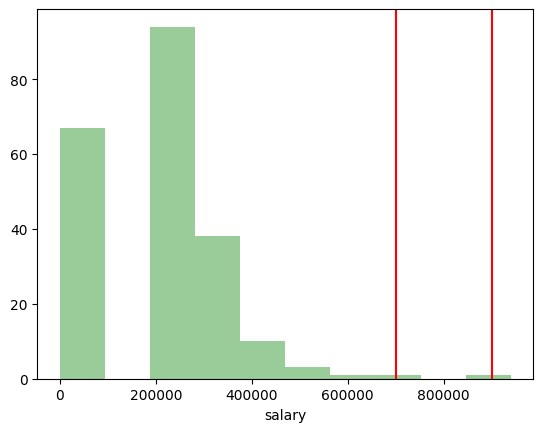

In [62]:
get_pdf_probability(dataset['salary'].fillna(0),700000,900000)

In [ ]:
#Solution:
#For the salary range from 700000 to 900000, probability is showing as 0.05% hence 0.05% students are getting salary between the range of 
#700000 to 900000

In [67]:
#11)Test the similarity between the degree_t(Sci&Tech)with respect to etest_p and mba_p at significance level of 5%.(Make decision using Hypothesis
#Testing)
from scipy.stats import ttest_rel
com_etest=dataset[dataset['degree_t']=='Sci&Tech']['etest_p']
com_mba=dataset[dataset['degree_t']=='Sci&Tech']['mba_p']
ttest_rel(com_etest,com_mba)


TtestResult(statistic=np.float64(5.0049844583693615), pvalue=np.float64(5.5179206005054e-06), df=np.int64(58))

In [68]:
#Solution
#Probability valule "pvalue=np.float64(5.5179206005054e-06(0.00000552)" is lower than 0.05.
#Reject the null hypothesis.
#Both entrance test and MBA passmarks are statistically significant for the category of degree's specilization Sci&Tech students.
#So we predict in future by using this statistical significant data.

In [69]:
#2)Which parameter is highly correlated with salary?
dataset[quan].corr()

,sl_no,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary,status_Placed
sl_no,1.000000,-0.078155,-0.085711,-0.088281,0.063636,0.022327,0.063764,-0.026859
ssc_p,-0.078155,1.000000,0.511472,0.538404,0.261993,0.388478,0.035330,0.607889
hsc_p,-0.085711,0.511472,1.000000,0.434206,0.245113,0.354823,0.076819,0.491228
degree_p,-0.088281,0.538404,0.434206,1.000000,0.224470,0.402364,-0.019272,0.479861
etest_p,0.063636,0.261993,0.245113,0.224470,1.000000,0.218055,0.178307,0.127639
mba_p,0.022327,0.388478,0.354823,0.402364,0.218055,1.000000,0.175013,0.076922
salary,0.063764,0.035330,0.076819,-0.019272,0.178307,0.175013,1.000000,NaN
status_Placed,-0.026859,0.607889,0.491228,0.479861,0.127639,0.076922,NaN,1.000000


In [70]:
#Solution:
#Entrance Test pass mark data has better correlation with Salary.
#It indicates that better low degree <0.54
#Entrance test is better inversely propotional to Salary

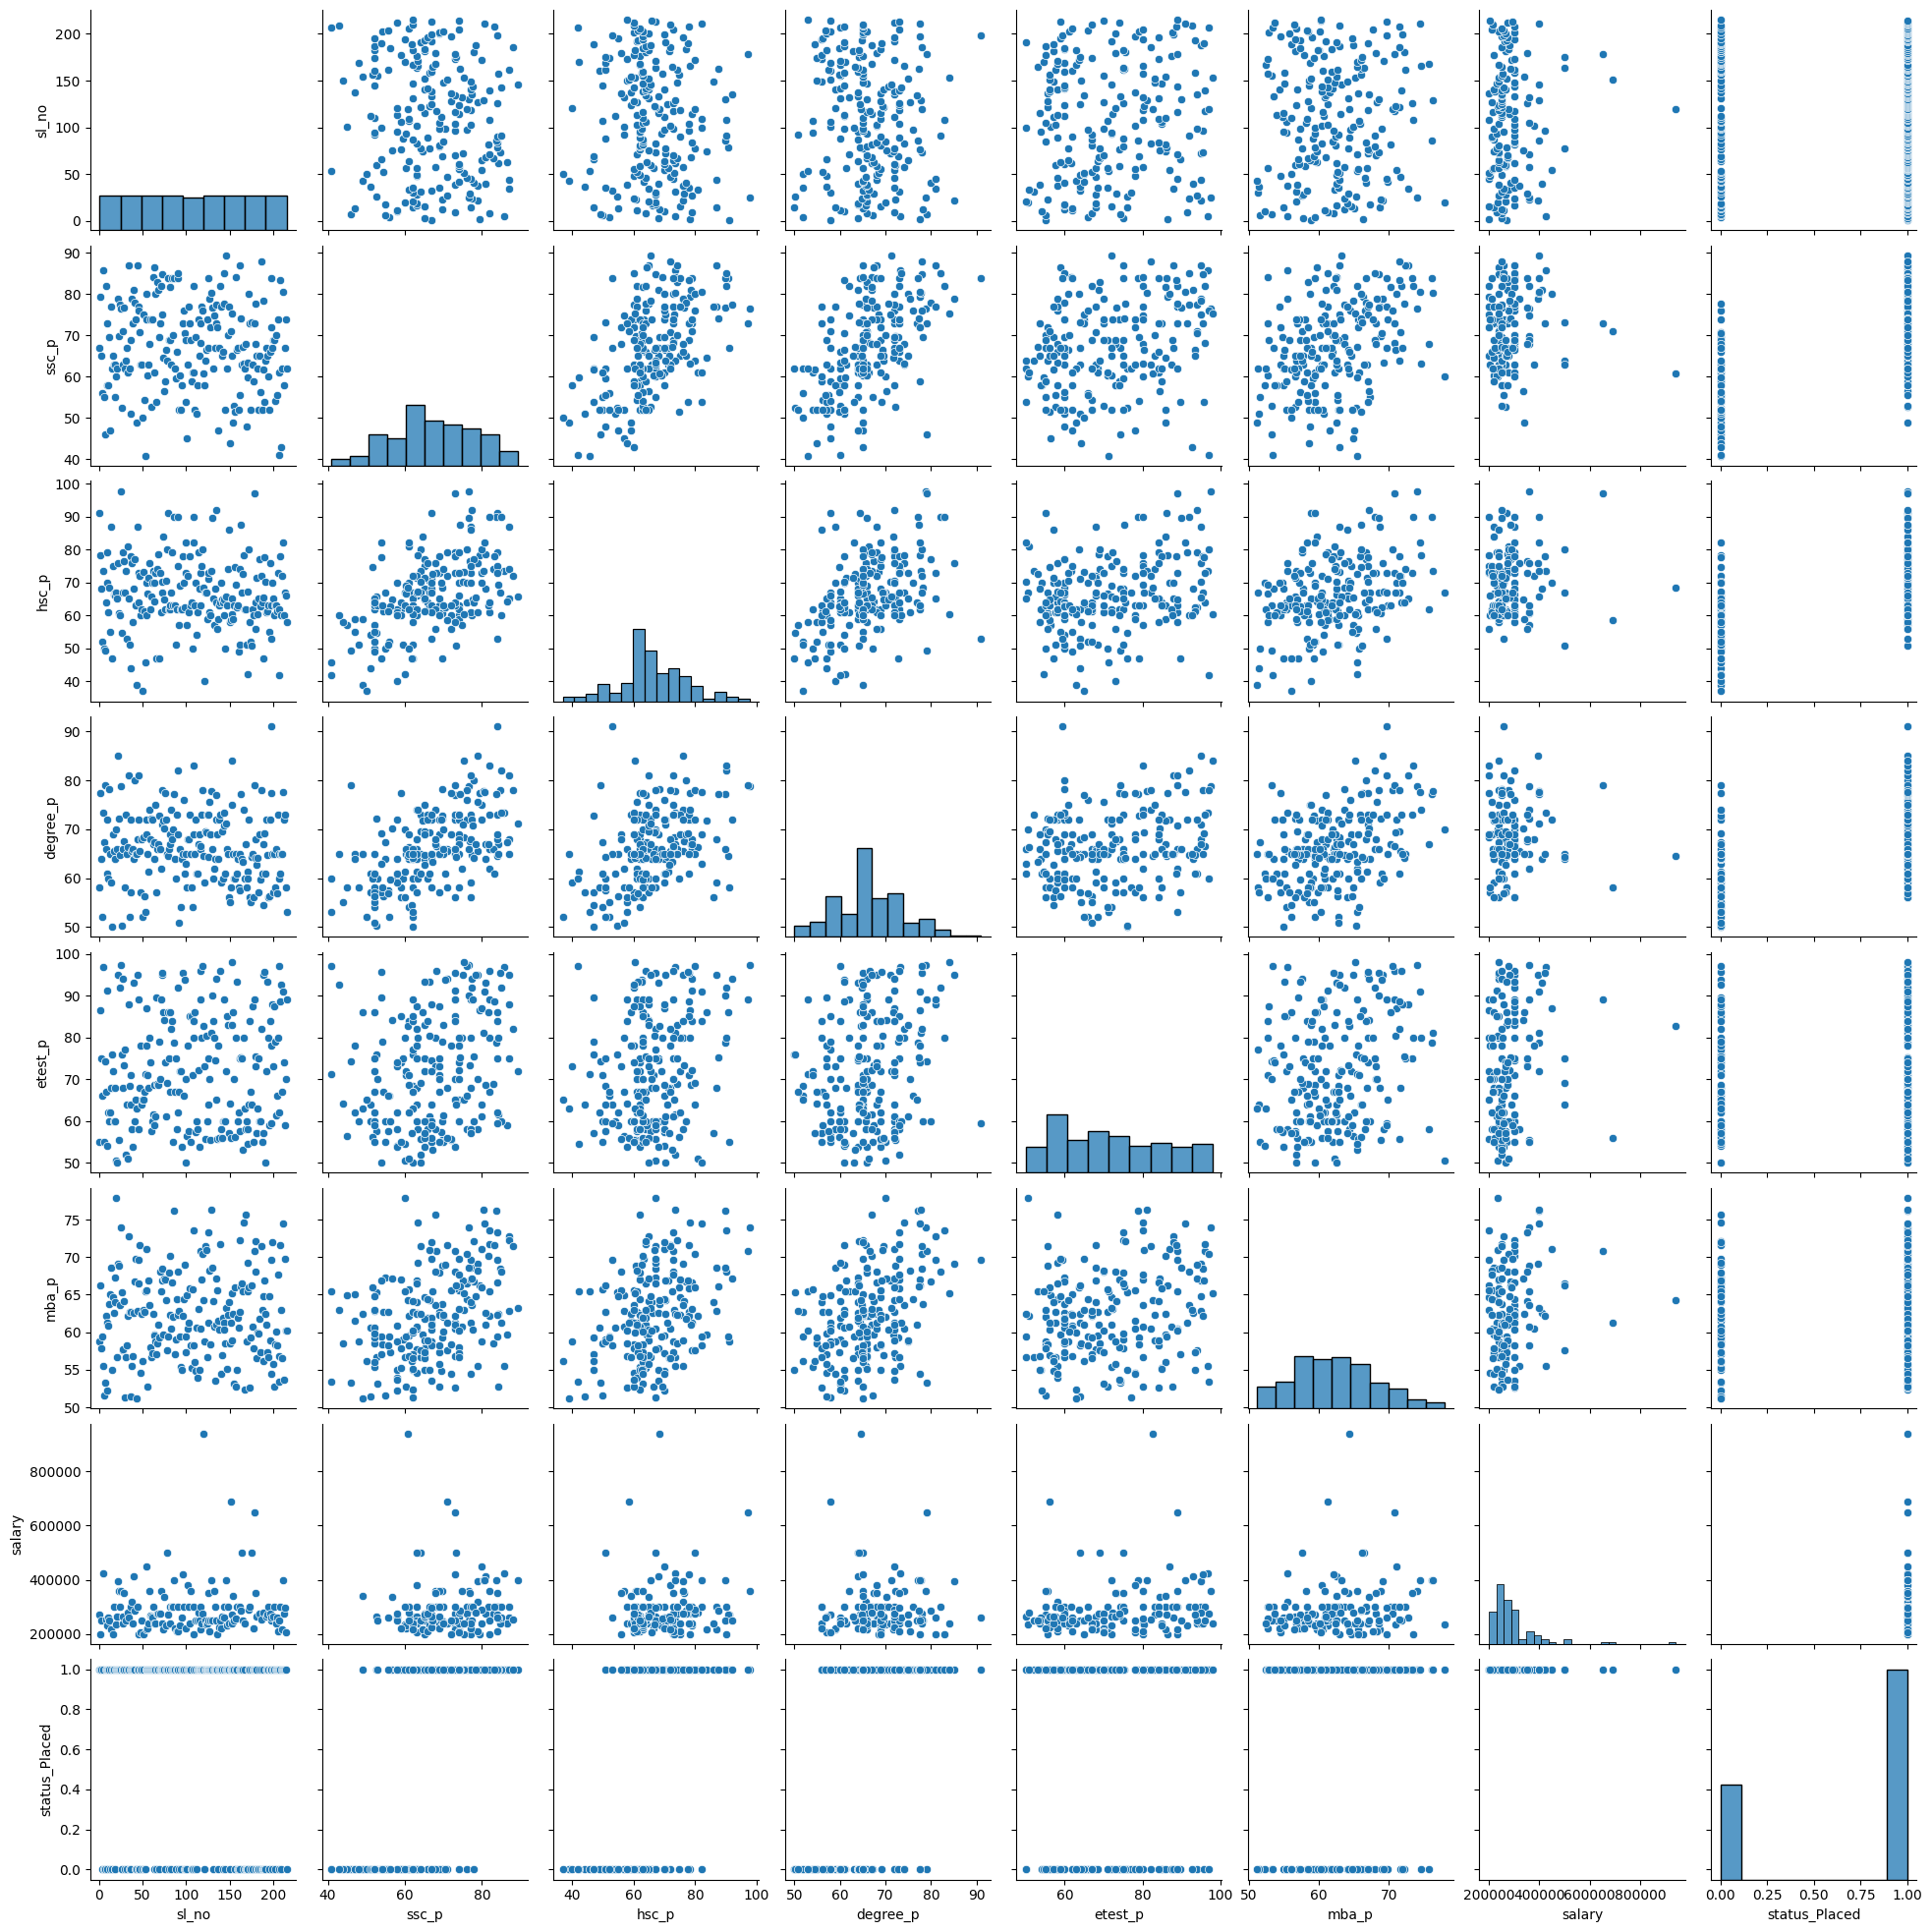

In [73]:
#13) plot any useful graph and explain it.
import seaborn as sbA
sb.pairplot(dataset)

In [74]:
#Solution:
#By using this graph we can see Bi-variate analysis of two columns.
#Can see diagonal analysis of Uni-variate as well for linear
#in single view we see complete dataset.
